In [20]:
import os
import osmnx as ox
import csv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

In [21]:
PATH_FILE = "./outputs/capability_to_eat.csv"

dati_capability_to_eat = []

colonne = [
    "lat",
    "lon",
    "capability_to_eat"
]

# node_id,lat,lon,capability_to_eat,dining_out_service,on_the_go_service

df = pd.read_csv(PATH_FILE, usecols=colonne)

C:\Users\davya\AppData\Local\Temp\ipykernel_22260\1849782079.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  md = df.pivot_table(


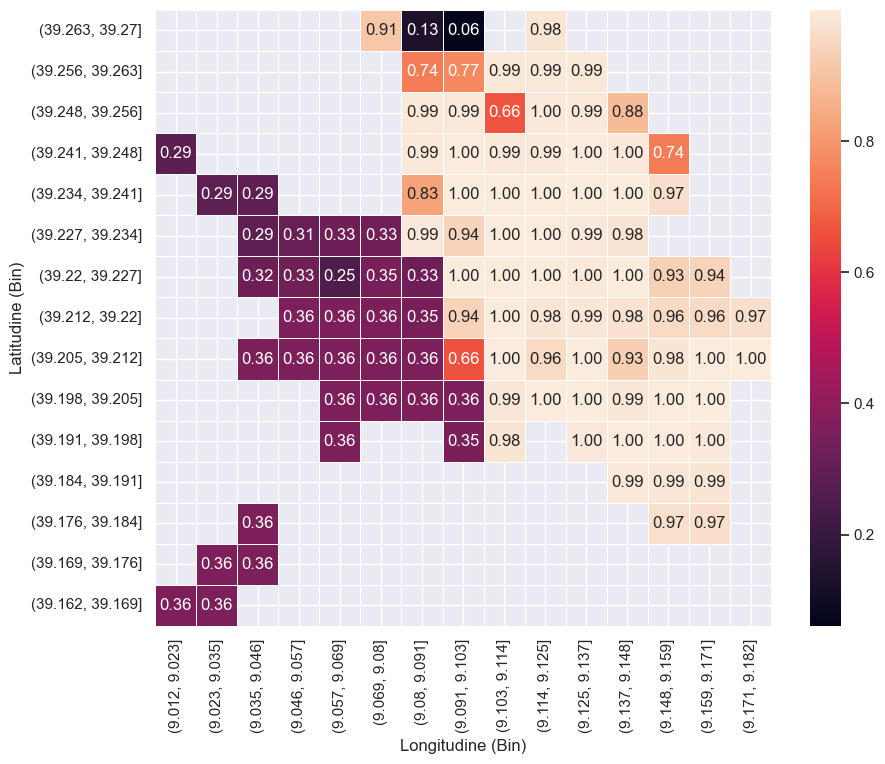

In [24]:
GRID_SIZE = 15
df["latitudine"] = pd.cut(df["lat"].round(3), bins=GRID_SIZE)
df["longitudine"] = pd.cut(df["lon"].round(3), bins=GRID_SIZE)

md = df.pivot_table(
    index="latitudine", 
    columns="longitudine", 
    values="capability_to_eat",
    aggfunc="mean"
) 

# per avere il Nord in alto
md = md.sort_index(ascending=False)

# VISUALIZZAZIONE
f, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    md, 
    annot=True,     
    fmt=".2f",      
    cmap="rocket", 
    cbar=True,
    square=True,    
    linewidths=.5   
)

ax.set_xlabel("Longitudine (Bin)")
ax.set_ylabel("Latitudine (Bin)")

plt.show()

Download del grafo in corso (questo richiederà un momento)...
Grafo salvato in cagliari_graph.graphml


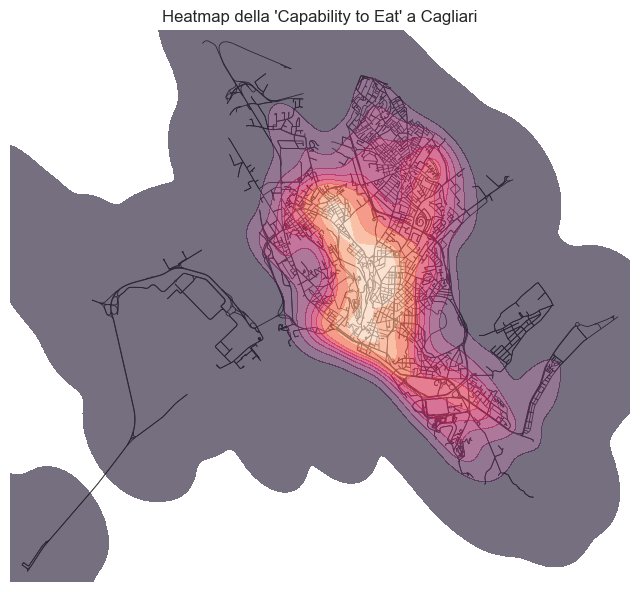

In [23]:
# 1. Configurazione file e luogo
place_name = "Cagliari, Italy"
file_path = "cagliari_graph.graphml"

# 2. Controllo se il grafo esiste già localmente
if os.path.exists(file_path):
    print(f"Caricamento del grafo da {file_path}...")
    G = ox.load_graphml(file_path)
else:
    print("Download del grafo in corso (questo richiederà un momento)...")
    G = ox.graph_from_place(place_name, network_type='drive')
    # Salvataggio per usi futuri
    ox.save_graphml(G, filepath=file_path)
    print(f"Grafo salvato in {file_path}")

# --- Supponiamo che il tuo DataFrame 'df' sia già caricato ---
# Se devi caricarlo: df = pd.read_csv("tuo_file.csv")
# Esempio rapido per rendere il codice eseguibile:
# df = pd.DataFrame({'lat': [39.22, 39.21], 'lon': [9.11, 9.12], 'capability_to_eat': [10, 20]})

# 3. Creazione del plot
# Usiamo ox.plot_graph per ottenere l'oggetto 'ax' (l'asse del grafico)
fig, ax = ox.plot_graph(
    G, 
    show=False, 
    close=False, 
    edge_color="#444444", 
    edge_linewidth=0.6, 
    node_size=0, 
    bgcolor="white"
)

# 4. Sovrapposizione del KDE plot usando lo stesso 'ax'
sns.kdeplot(
    data=df,
    x="lon",           # Assicurati che i nomi delle colonne coincidano
    y="lat",
    weights="capability_to_eat",  
    fill=True,
    cmap="rocket",
    thresh=0.00001,
    alpha=0.6,          # Abbassiamo leggermente l'alpha per vedere le strade sotto
    ax=ax               # <--- FONDAMENTALE per la sovrapposizione
)

# Impostazioni finali
ax.set_title("Heatmap della 'Capability to Eat' a Cagliari")
plt.show()